# End-to-End E-Commerce Customer Analytics & Retention Strategy

**Author:** Moh. Yusril Lukman Hakim  
**Tools:** Python (Pandas, Scikit-Learn, Imbalanced-Learn, Matplotlib, Seaborn)  
**Dataset:** [E-Commerce Customer Churn Dataset (Kaggle)](https://www.kaggle.com/datasets/samuelsemaya/e-commerce-customer-churn)

---

## Executive Overview

This project delivers an end-to-end Machine Learning pipeline to predict customer churn, identify key attrition drivers, and enable data-driven retention strategies. The workflow is structured into **Three Core Analytical Pillars**:

1. **Analytical Pillar 1: Data Preprocessing, Visual EDA & Class Balancing** (Cleaning missing values, visualizing key churn factors, One-Hot Encoding, and SMOTE balancing)
2. **Analytical Pillar 2: Predictive Modeling & Performance Evaluation** (Random Forest training, Recall optimization, and ROC-AUC evaluation)
3. **Analytical Pillar 3: Feature Importance Analysis & Strategic Business Recommendations** (Extracting top churn drivers and exporting risk-scored customer lists for CRM intervention)

---

## Setup Library & Environment Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Analytical Pillar 1: Data Preprocessing, Visual EDA & Class Balancing

This pillar prepares raw transactional data through three core steps:

* **Sub-Pillar 1.1 (Data Cleaning):** Imputes missing numerical values with medians and drops non-predictive features (`CustomerID`).
* **Sub-Pillar 1.2 (Visual EDA):** Explores bivariate relationships between key factors (`Complain`, `PreferedOrderCat`, `Tenure`) and `Churn`.
* **Sub-Pillar 1.3 (Feature Encoding & SMOTE):** Applies One-Hot Encoding, performs a 80/20 stratified split, and balances the training set using SMOTE to prevent data leakage.

### Sub-Pillar 1.1: Data Cleaning & Imputation
Handles missing values by imputing numeric features with their median and drops non-predictive identifiers like `CustomerID`.

In [8]:
df = pd.read_csv('/home/stradivarius/data_ecommerce_customer_churn.csv')

if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

### Sub-Pillar 1.2: Visual Exploratory Data Analysis (EDA)
Visualizes key bivariate relationships (Complain, Preferred Order Category, Tenure) against customer churn status before feature encoding.

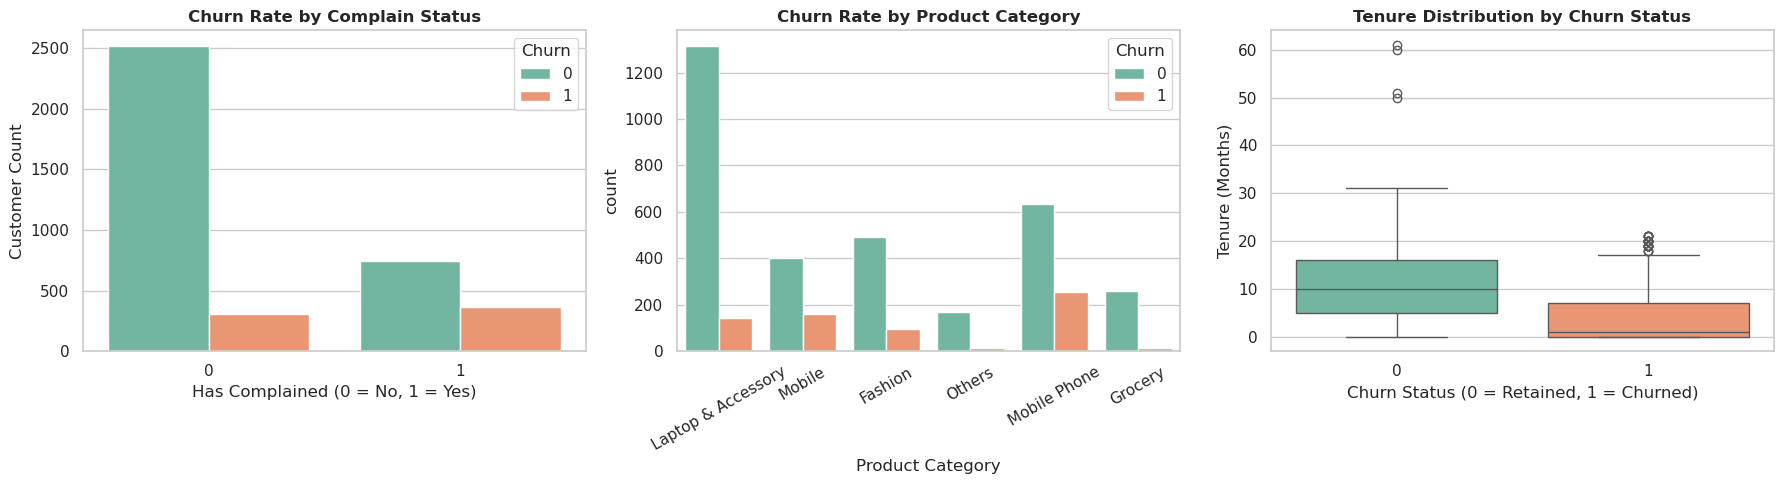

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Churn Rate by Complain Status
sns.countplot(data=df, x='Complain', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn Rate by Complain Status', fontweight='bold')
axes[0].set_xlabel('Has Complained (0 = No, 1 = Yes)')
axes[0].set_ylabel('Customer Count')

# 2. Churn Rate by Preferred Product Category
sns.countplot(data=df, x='PreferedOrderCat', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('Churn Rate by Product Category', fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].tick_params(axis='x', rotation=30)

# 3. Tenure Distribution by Churn Status
sns.boxplot(data=df, x='Churn', y='Tenure', ax=axes[2], palette='Set2', hue='Churn', legend=False)
axes[2].set_title('Tenure Distribution by Churn Status', fontweight='bold')
axes[2].set_xlabel('Churn Status (0 = Retained, 1 = Churned)')
axes[2].set_ylabel('Tenure (Months)')

plt.tight_layout()
plt.savefig('eda_churn_factors.png', dpi=300)
plt.show()

### Sub-Pillar 1.3: Feature Encoding & Class Balancing (SMOTE)
Applies One-Hot Encoding on categorical attributes, performs a 80/20 stratified train-test split, and balances class distribution using SMOTE on training data.

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original Train Set Target Distribution:\n{y_train.value_counts()}\n")
print(f"Resampled Train Set Target Distribution:\n{y_train_resampled.value_counts()}")

Original Train Set Target Distribution:
Churn
0    2613
1     539
Name: count, dtype: int64

Resampled Train Set Target Distribution:
Churn
1    2613
0    2613
Name: count, dtype: int64


## Analytical Pillar 2: Predictive Modeling & Performance Evaluation

This pillar focuses on training the machine learning model and evaluating its predictive capabilities:

* **Model Training:** Fits a Random Forest Classifier on the SMOTE-resampled training set to capture complex customer behavior patterns.
* **Predictive Inference:** Generates binary churn predictions and individual risk probability scores on the unseen test dataset.
* **Performance Evaluation:** Measures model performance using a Classification Report and ROC-AUC Score, prioritizing Recall for high-risk churned customers.

In [11]:
# Model Training
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predictive Inference
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Performance Evaluation
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       654
           1       0.79      0.80      0.79       135

    accuracy                           0.93       789
   macro avg       0.87      0.88      0.88       789
weighted avg       0.93      0.93      0.93       789

ROC-AUC Score: 0.9524


## Analytical Pillar 3: Feature Importance Analysis & Strategic Business Recommendations

This pillar extracts key churn drivers to formulate actionable business strategies and exports risk-scored predictions for operational retention campaigns:

* **Feature Importance Analysis:** Identifies and visualizes the top 10 features driving customer churn using the Random Forest model.
* **Risk Scoring & Data Exporting:** Consolidates test set predictions with calculated churn probabilities and exports the final dataset (`customer_churn_predictions.csv`) for targeted retention interventions.

### Sub-Pillar 3.1: Feature Importance Analysis
Identifies and visualizes the top 10 features driving customer churn using the Random Forest model to pinpoint critical retention drivers.

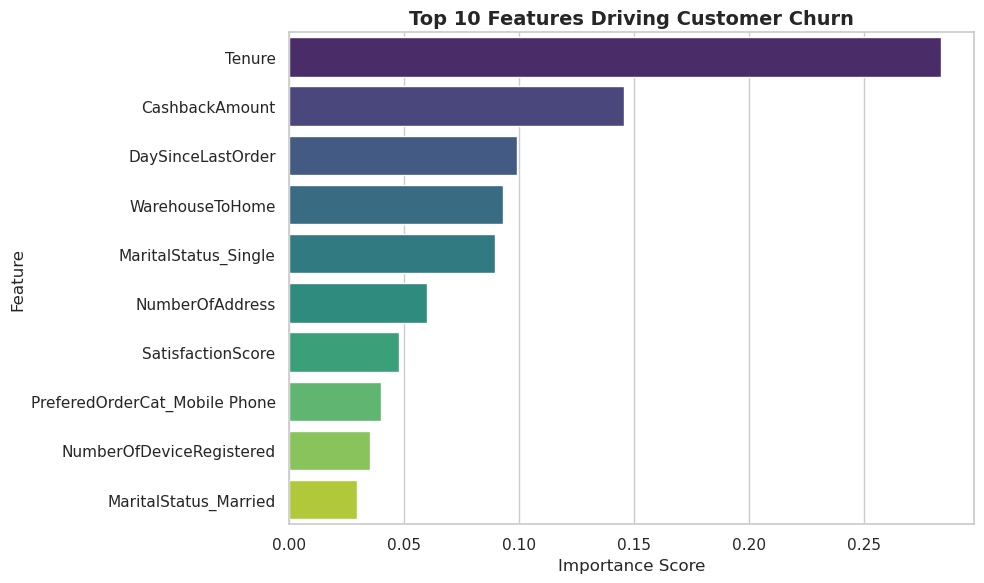

=== TOP 5 CHURN DRIVERS ===
                 Feature  Importance
0                 Tenure    0.283441
7         CashbackAmount    0.145790
6      DaySinceLastOrder    0.098894
1        WarehouseToHome    0.093034
14  MaritalStatus_Single    0.089551


In [12]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_imp_df.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False,
    palette='viridis'
)
plt.title('Top 10 Features Driving Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("=== TOP 5 CHURN DRIVERS ===")
print(feature_imp_df.head(5))

### Sub-Pillar 3.2: Risk Scoring & Prediction Exporting
Consolidates test set predictions with calculated churn probability scores and exports the sorted risk dataset (customer_churn_predictions.csv) for targeted business interventions.

In [13]:
df_test_results = X_test.copy()
df_test_results['Actual_Churn'] = y_test
df_test_results['Predicted_Churn'] = y_pred
df_test_results['Churn_Probability (%)'] = (y_pred_proba * 100).round(2)
df_test_results = df_test_results.sort_values(by='Churn_Probability (%)', ascending=False)

df_test_results.to_csv('customer_churn_predictions.csv', index=False)
print("File 'customer_churn_predictions.csv' successfully saved!")

File 'customer_churn_predictions.csv' successfully saved!
